<a href="https://colab.research.google.com/github/sunaina1302/ATM-transaction-Analysis-and-Dashboard/blob/main/PCA_DBSCAN_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("shwetabh123/mall-customers")

Using Colab cache for faster access to the 'mall-customers' dataset.


In [3]:
import pandas as pd
df = pd.read_csv(path + "/Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.replace("Male",0,inplace=True)
df.replace("Female",1,inplace=True)
df.head()

/tmp/ipykernel_8744/266215180.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace("Female",1,inplace=True)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


In [5]:
X = df[(["Annual Income (k$)","Spending Score (1-100)"])]

In [6]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled =scaler.fit_transform(X)

In [7]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5,min_samples=5)
labels = dbscan.fit_predict(X_scaled)

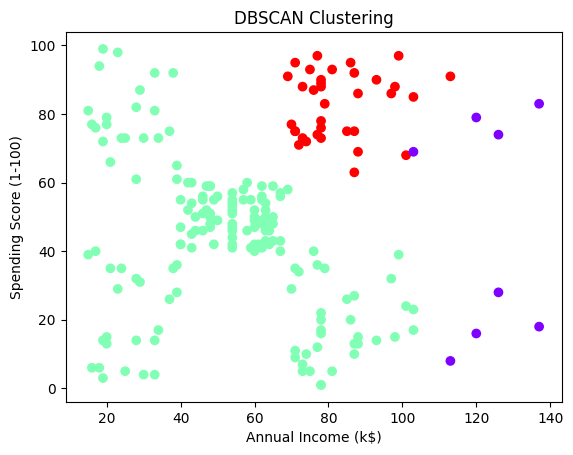

In [8]:
import matplotlib.pyplot as plt

plt.scatter(X.iloc[:,0], X.iloc[:,1], c=labels,cmap='rainbow')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")
plt.show()

/tmp/ipykernel_8744/2227687893.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette='viridis')


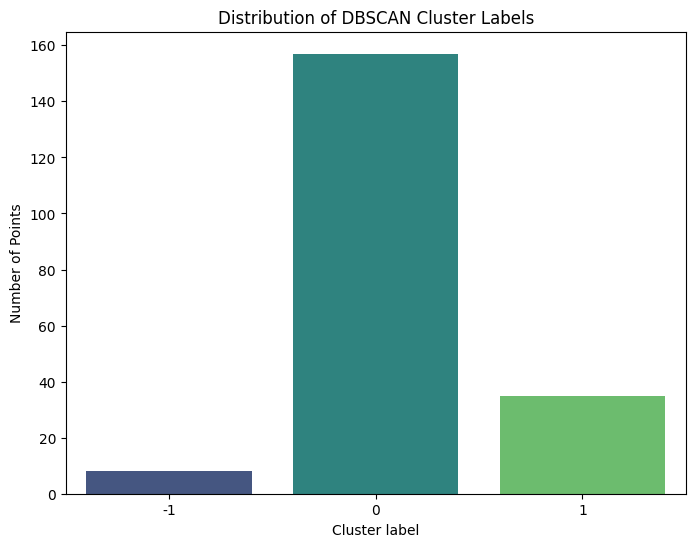

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x=labels, palette='viridis')
plt.title('Distribution of DBSCAN Cluster Labels')
plt.xlabel('Cluster label')
plt.ylabel('Number of Points')
plt.show()

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

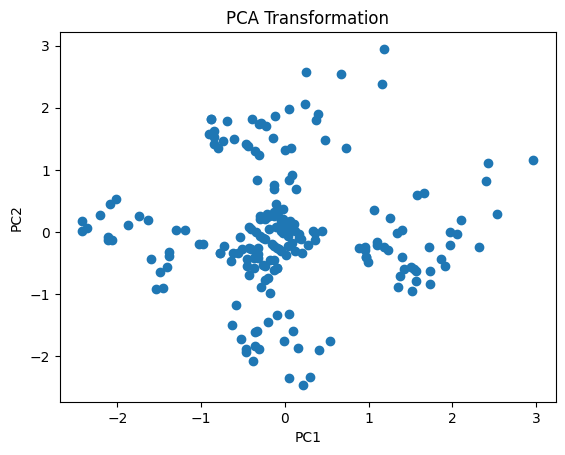

In [11]:
plt.scatter(X_pca[:,0], X_pca[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Transformation")
plt.show()